# **Haseeb Ul Hassan**

**MSCS25003**

**Computer Vision Assignment no: 1**

Installs OpenCV (headless version, since Colab has no display) and imports the libraries needed: cv2 for template matching, numpy for array math, cv2_imshow to render images inline, and files to upload from your compute

In [1]:
!pip install opencv-python-headless -q

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

Opens a file-picker twice — once for your source image, once for your template — reads both from disk with cv2.imread, and prints their shapes as a sanity check.

In [2]:
print("Upload your SOURCE image (the scene to search in):")
uploaded_image = files.upload()
image_path = list(uploaded_image.keys())[0]

print("Upload your TEMPLATE image (the small patch to find):")
uploaded_template = files.upload()
template_path = list(uploaded_template.keys())[0]

image = cv2.imread(image_path)
template = cv2.imread(template_path)

print("Image shape:", image.shape)
print("Template shape:", template.shape)

Upload your SOURCE image (the scene to search in):


Saving input.png to input.png
Upload your TEMPLATE image (the small patch to find):


Saving template.png to template.png
Image shape: (280, 326, 3)
Template shape: (57, 45, 3)


Defines the four building blocks: draw_corner_dots (marks the 4 bbox corners in red), single_match (finds the one best-scoring position), non_max_suppression (removes duplicate overlapping detections), and multi_match (finds every position above a score threshold, then runs NMS on them).

In [6]:
def draw_corner_dots(image, top_left, bottom_right, radius=3, color=(0, 0, 255), thickness=-1):
    x1, y1 = top_left
    x2, y2 = bottom_right
    corners = [(x1, y1), (x2, y1), (x1, y2), (x2, y2)]
    for (cx, cy) in corners:
        cv2.circle(image, (cx, cy), radius, color, thickness)
    return image


def single_match(image_gray, template_gray, method=cv2.TM_CCOEFF_NORMED):
    h, w = template_gray.shape[:2]
    result = cv2.matchTemplate(image_gray, template_gray, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    if method in (cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED):
        top_left, score = min_loc, min_val
    else:
        top_left, score = max_loc, max_val

    bottom_right = (top_left[0] + w, top_left[1] + h)
    return [(top_left, bottom_right, score)]


def non_max_suppression(boxes, overlap_thresh=0.3):
    if len(boxes) == 0:
        return []
    x1 = np.array([b[0][0] for b in boxes], dtype=float)
    y1 = np.array([b[0][1] for b in boxes], dtype=float)
    x2 = np.array([b[1][0] for b in boxes], dtype=float)
    y2 = np.array([b[1][1] for b in boxes], dtype=float)
    scores = np.array([b[2] for b in boxes], dtype=float)

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        remaining = np.where(iou <= overlap_thresh)[0]
        order = order[remaining + 1]

    return [boxes[i] for i in keep]


def multi_match(image_gray, template_gray, threshold=0.8, method=cv2.TM_CCOEFF_NORMED, overlap_thresh=0.3):
    h, w = template_gray.shape[:2]
    result = cv2.matchTemplate(image_gray, template_gray, method)

    if method in (cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED):
        locations = np.where(result <= (1 - threshold))
    else:
        locations = np.where(result >= threshold)

    boxes = []
    for (y, x) in zip(*locations):
        top_left = (int(x), int(y))
        bottom_right = (int(x) + w, int(y) + h)
        score = float(result[y, x])
        boxes.append((top_left, bottom_right, score))

    return non_max_suppression(boxes, overlap_thresh=overlap_thresh)

### Converts both images to grayscale, shows the template, runs single_match to find the best position, draws red dots on its 4 corners, and displays the result.

top_left=(162, 120), bottom_right=(207, 177), score=1.000


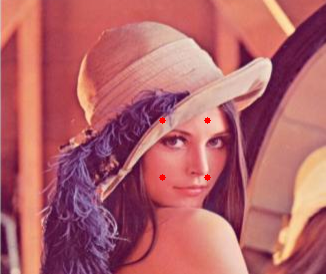

In [7]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

boxes = single_match(image_gray, template_gray)

output = image.copy()
for top_left, bottom_right, score in boxes:
    print(f"top_left={top_left}, bottom_right={bottom_right}, score={score:.3f}")
    draw_corner_dots(output, top_left, bottom_right)

cv2_imshow(output)

### Same idea but for repeated templates — shows the template, runs multi_match with a score threshold, prints how many matches were found, and draws corner dots on all of them.
**In this image there is single match that's why the same output**

Template:


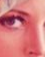

top_left=(162, 120), bottom_right=(207, 177), score=1.000
Result:


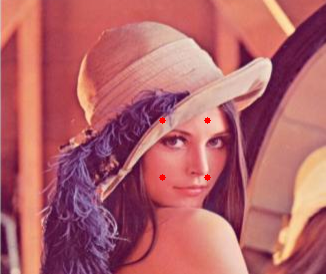

In [8]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

print("Template:")
cv2_imshow(template)

boxes = single_match(image_gray, template_gray)

output = image.copy()
for top_left, bottom_right, score in boxes:
    print(f"top_left={top_left}, bottom_right={bottom_right}, score={score:.3f}")
    draw_corner_dots(output, top_left, bottom_right)

print("Result:")
cv2_imshow(output)